In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

df = pd.read_csv("All India Consumer Price Index.csv")
print(df.head())
df.info()
print(df.describe(include="all"))

        Sector  Year  ... Miscellaneous  General index
0        Rural  2013  ...         104.0          105.1
1        Urban  2013  ...         103.7          104.0
2  Rural+Urban  2013  ...         103.9          104.6
3        Rural  2013  ...         104.4          105.8
4        Urban  2013  ...         104.3          104.7

[5 rows x 30 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Sector                               365 non-null    object 
 1   Year                                 365 non-null    int64  
 2   Month                                365 non-null    object 
 3   Cereals and products                 362 non-null    float64
 4   Meat and fish                        359 non-null    float64
 5   Egg                                  362 non-null    float64
 6   Milk and 

In [2]:
df.to_excel("consumer_price_index.xlsx", index=False)
print("CSV converted to Excel successfully!")

CSV converted to Excel successfully!


In [3]:
df_excel = pd.read_excel("consumer_price_index.xlsx")
df_excel.to_csv("consumer_price_index_converted.csv", index=False)
print("Excel converted to CSV successfully!")

Excel converted to CSV successfully!


In [4]:
df_csv = pd.read_csv("consumer_price_index_converted.csv")
print(df_csv.head())

        Sector  Year  ... Miscellaneous  General index
0        Rural  2013  ...         104.0          105.1
1        Urban  2013  ...         103.7          104.0
2  Rural+Urban  2013  ...         103.9          104.6
3        Rural  2013  ...         104.4          105.8
4        Urban  2013  ...         104.3          104.7

[5 rows x 30 columns]


In [5]:
df_csv.to_json("consumer_price_index.json", orient="records", indent=4)
print("JSON file created successfully!")

JSON file created successfully!


In [6]:
df_json = pd.read_json("consumer_price_index.json")
print(df_json.head())
df_json.info()
print(df_json.describe(include="all"))

        Sector  Year  ... Miscellaneous  General index
0        Rural  2013  ...         104.0          105.1
1        Urban  2013  ...         103.7          104.0
2  Rural+Urban  2013  ...         103.9          104.6
3        Rural  2013  ...         104.4          105.8
4        Urban  2013  ...         104.3          104.7

[5 rows x 30 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Sector                               365 non-null    object 
 1   Year                                 365 non-null    int64  
 2   Month                                365 non-null    object 
 3   Cereals and products                 362 non-null    float64
 4   Meat and fish                        359 non-null    float64
 5   Egg                                  362 non-null    float64
 6   Milk and 

       Sector         Year  ... Miscellaneous  General index
count     365   365.000000  ...    359.000000     359.000000
unique      3          NaN  ...           NaN            NaN
top     Rural          NaN  ...           NaN            NaN
freq      122          NaN  ...           NaN            NaN
mean      NaN  2017.608219  ...    133.438997     138.807799
std       NaN     2.965449  ...     20.198469      19.831978
min       NaN  2013.000000  ...    103.700000     104.000000
25%       NaN  2015.000000  ...    116.400000     123.100000
50%       NaN  2018.000000  ...    128.900000     136.400000
75%       NaN  2020.000000  ...    149.150000     154.950000
max       NaN  2023.000000  ...    177.900000     178.000000

[11 rows x 30 columns]


In [7]:
conn = sqlite3.connect("consumer_price_index.db")
df.to_sql("consumer_price_index", conn, if_exists="replace", index=False)
conn.close()
print("Data exported to SQLite successfully!")

Data exported to SQLite successfully!


In [8]:
conn = sqlite3.connect("consumer_price_index.db")
df_sql = pd.read_sql("SELECT * FROM consumer_price_index", conn)
print(df_sql.head())
df_sql.info()
print(df_sql.describe(include="all"))
conn.close()

        Sector  Year  ... Miscellaneous  General index
0        Rural  2013  ...         104.0          105.1
1        Urban  2013  ...         103.7          104.0
2  Rural+Urban  2013  ...         103.9          104.6
3        Rural  2013  ...         104.4          105.8
4        Urban  2013  ...         104.3          104.7

[5 rows x 30 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Sector                               365 non-null    object 
 1   Year                                 365 non-null    int64  
 2   Month                                365 non-null    object 
 3   Cereals and products                 362 non-null    float64
 4   Meat and fish                        359 non-null    float64
 5   Egg                                  362 non-null    float64
 6   Milk and 

In [9]:
print(df_sql.columns)

Index(['Sector', 'Year', 'Month', 'Cereals and products', 'Meat and fish',
       'Egg', 'Milk and products', 'Oils and fats', 'Fruits', 'Vegetables',
       'Pulses and products', 'Sugar and Confectionery', 'Spices',
       'Non-alcoholic beverages', 'Prepared meals, snacks, sweets etc.',
       'Food and beverages', 'Pan, tobacco and intoxicants', 'Clothing',
       'Footwear', 'Clothing and footwear', 'Housing', 'Fuel and light',
       'Household goods and services', 'Health', 'Transport and communication',
       'Recreation and amusement', 'Education', 'Personal care and effects',
       'Miscellaneous', 'General index'],
      dtype='object')


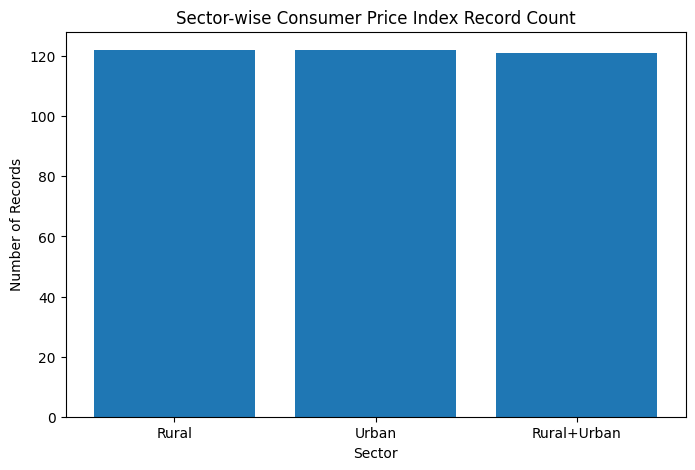

In [10]:
sector = df_sql["Sector"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(sector.index, sector.values)
plt.title("Sector-wise Consumer Price Index Record Count")
plt.xlabel("Sector")
plt.ylabel("Number of Records")
plt.show()

In [11]:
print("======================================")
print("Experiment 2 Completed Successfully")
print("Dataset Shape:", df_sql.shape)
print("JSON Conversion: Successful")
print("SQLite Storage: Successful")
print("SQLite Retrieval: Successful")
print("Visualization: Successful")
print("======================================")

Experiment 2 Completed Successfully
Dataset Shape: (365, 30)
JSON Conversion: Successful
SQLite Storage: Successful
SQLite Retrieval: Successful
Visualization: Successful
